In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

## Регрессия

   Education  JoiningYear       City  PaymentTier  Age  Gender EverBenched  \
0  Bachelors         2017  Bangalore            3   34    Male          No   
1  Bachelors         2013       Pune            1   28  Female          No   
2  Bachelors         2014  New Delhi            3   38  Female          No   
3    Masters         2016  Bangalore            3   27    Male          No   
4    Masters         2017       Pune            3   24    Male         Yes   

   ExperienceInCurrentDomain  LeaveOrNot  
0                          0           0  
1                          3           1  
2                          2           0  
3                          5           1  
4                          2           1  
(4653, 9)
Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot     

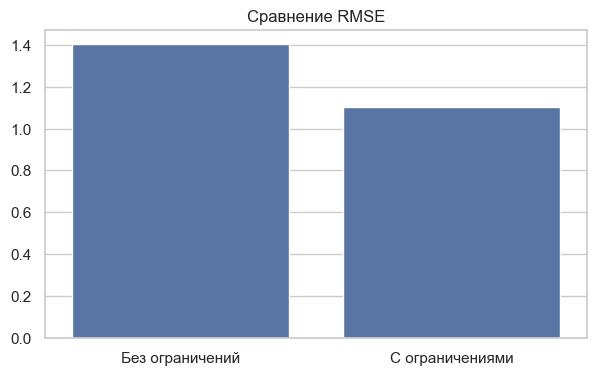

Лучшая модель: с ограничениями


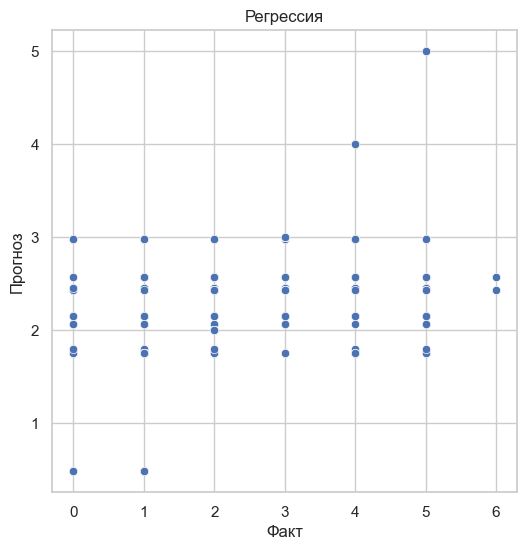

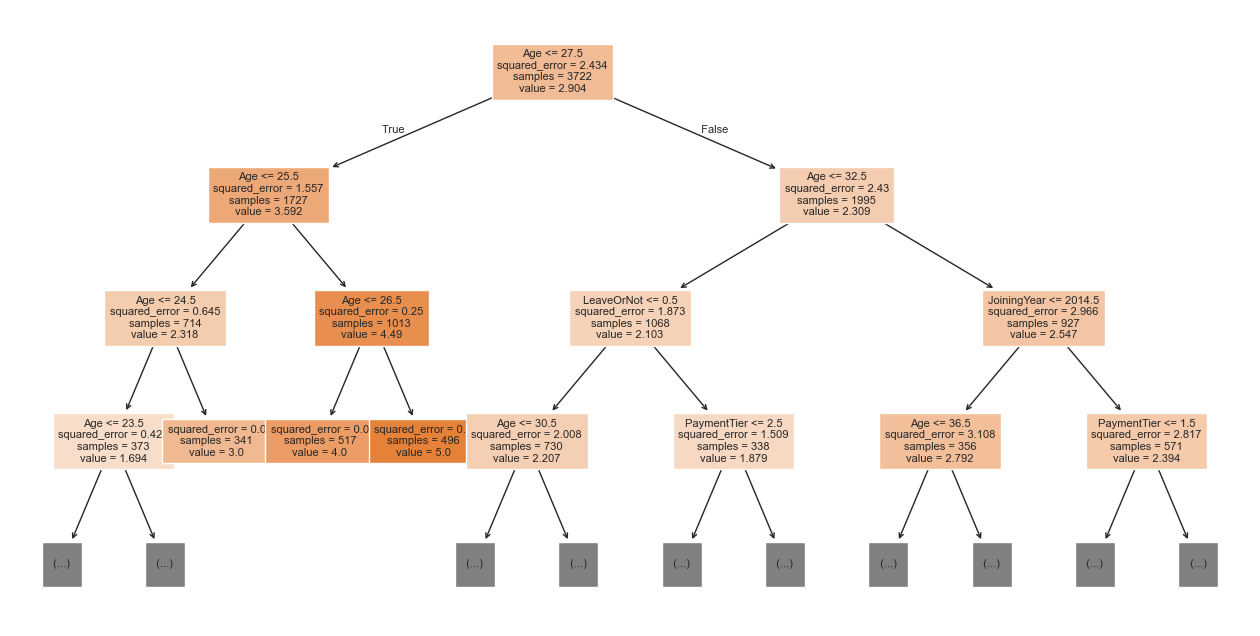

In [3]:
df = pd.read_csv('employeeDataset.csv')
print(df.head())
print(df.shape)
print(df.isna().sum())

target = 'ExperienceInCurrentDomain'
X = df.drop(columns=[target])
y = df[target]

for col in X.select_dtypes(include='number').columns:
    X[col] = X[col].fillna(X[col].median())

for col in X.select_dtypes(exclude='number').columns:
    X[col] = X[col].fillna(X[col].mode()[0])

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree1 = DecisionTreeRegressor(random_state=42)
tree1.fit(X_train, y_train)
pred1 = tree1.predict(X_test)

tree2 = DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=42)
tree2.fit(X_train, y_train)
pred2 = tree2.predict(X_test)

print('Модель без ограничений')
print('MAE:', mean_absolute_error(y_test, pred1))
print('RMSE:', root_mean_squared_error(y_test, pred1))
print('R2:', r2_score(y_test, pred1))
print()

print('Модель с ограничениями')
print('MAE:', mean_absolute_error(y_test, pred2))
print('RMSE:', root_mean_squared_error(y_test, pred2))
print('R2:', r2_score(y_test, pred2))

rmse1 = root_mean_squared_error(y_test, pred1)
rmse2 = root_mean_squared_error(y_test, pred2)

plt.figure(figsize=(7, 4))
sns.barplot(x=['Без ограничений', 'С ограничениями'], y=[rmse1, rmse2])
plt.title('Сравнение RMSE')
plt.show()

if rmse1 <= rmse2:
    best_model = tree1
    best_pred = pred1
    print('Лучшая модель: без ограничений')
else:
    best_model = tree2
    best_pred = pred2
    print('Лучшая модель: с ограничениями')

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=best_pred)
plt.xlabel('Факт')
plt.ylabel('Прогноз')
plt.title('Регрессия')
plt.show()

plt.figure(figsize=(16, 8))
plot_tree(best_model, filled=True, feature_names=X.columns, max_depth=3, fontsize=8)
plt.show()


## Классификация

   Education  JoiningYear       City  PaymentTier  Age  Gender EverBenched  \
0  Bachelors         2017  Bangalore            3   34    Male          No   
1  Bachelors         2013       Pune            1   28  Female          No   
2  Bachelors         2014  New Delhi            3   38  Female          No   
3    Masters         2016  Bangalore            3   27    Male          No   
4    Masters         2017       Pune            3   24    Male         Yes   

   ExperienceInCurrentDomain  LeaveOrNot  
0                          0           0  
1                          3           1  
2                          2           0  
3                          5           1  
4                          2           1  
(4653, 9)
Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot     

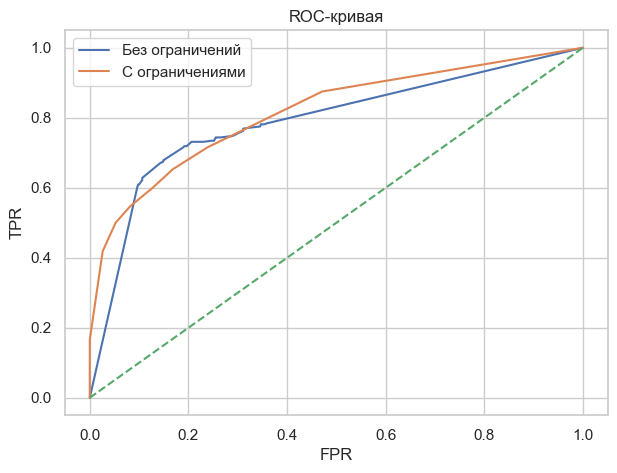

Лучшая модель: с ограничениями
              precision    recall  f1-score   support

           0       0.78      0.95      0.86       611
           1       0.83      0.50      0.62       320

    accuracy                           0.79       931
   macro avg       0.81      0.72      0.74       931
weighted avg       0.80      0.79      0.78       931



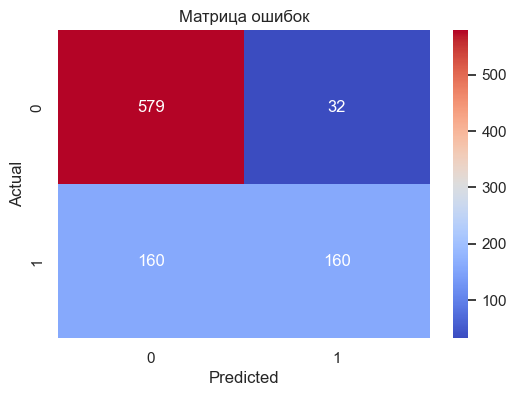

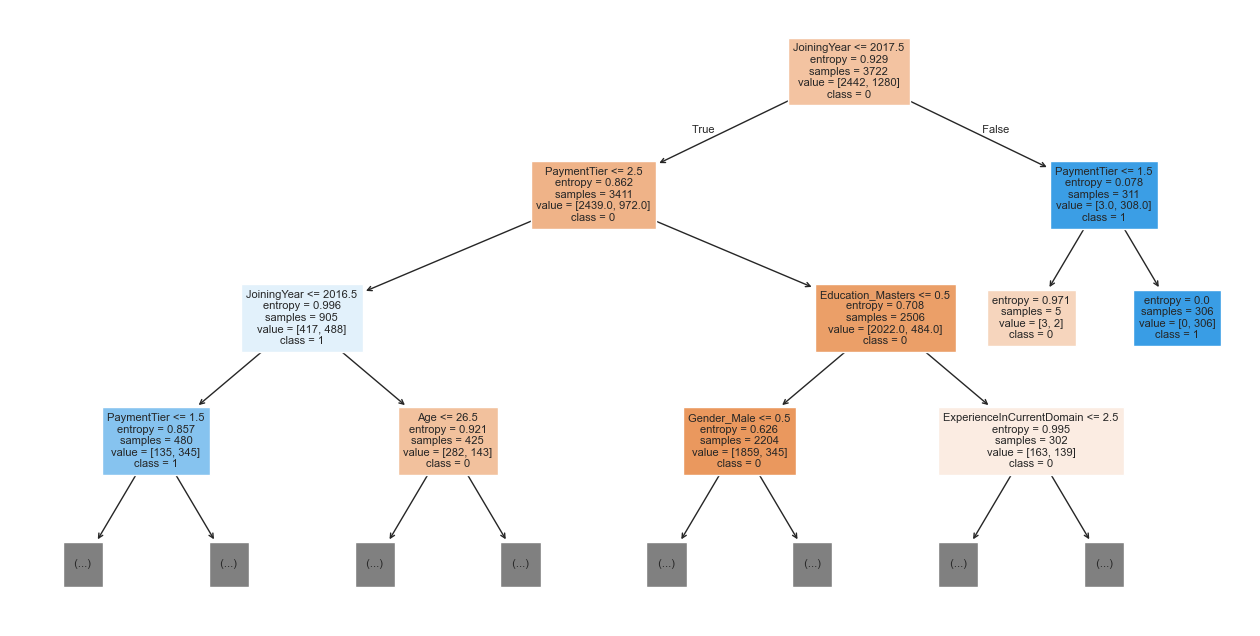

In [5]:
df = pd.read_csv('employeeDataset.csv')
print(df.head())
print(df.shape)
print(df.isna().sum())

target = 'LeaveOrNot'
X = df.drop(columns=[target])
y = df[target]

for col in X.select_dtypes(include='number').columns:
    X[col] = X[col].fillna(X[col].median())

for col in X.select_dtypes(exclude='number').columns:
    X[col] = X[col].fillna(X[col].mode()[0])

X = pd.get_dummies(X, drop_first=True)
print(y.value_counts())

if y.value_counts().min() >= 2:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree1 = DecisionTreeClassifier(random_state=42)
tree1.fit(X_train, y_train)
pred1 = tree1.predict(X_test)
proba1 = tree1.predict_proba(X_test)[:, 1]

tree2 = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, criterion='entropy', random_state=42)
tree2.fit(X_train, y_train)
pred2 = tree2.predict(X_test)
proba2 = tree2.predict_proba(X_test)[:, 1]

print('Модель без ограничений')
print('Accuracy:', accuracy_score(y_test, pred1))
print('Precision:', precision_score(y_test, pred1, zero_division=0))
print('Recall:', recall_score(y_test, pred1, zero_division=0))
print('F1:', f1_score(y_test, pred1, zero_division=0))
print()

print('Модель с ограничениями')
print('Accuracy:', accuracy_score(y_test, pred2))
print('Precision:', precision_score(y_test, pred2, zero_division=0))
print('Recall:', recall_score(y_test, pred2, zero_division=0))
print('F1:', f1_score(y_test, pred2, zero_division=0))

fpr1, tpr1, _ = roc_curve(y_test, proba1)
auc1 = auc(fpr1, tpr1)
fpr2, tpr2, _ = roc_curve(y_test, proba2)
auc2 = auc(fpr2, tpr2)

print('ROC-AUC без ограничений:', auc1)
print('ROC-AUC с ограничениями:', auc2)

plt.figure(figsize=(7, 5))
plt.plot(fpr1, tpr1, label='Без ограничений')
plt.plot(fpr2, tpr2, label='С ограничениями')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC-кривая')
plt.legend()
plt.show()

if auc1 >= auc2:
    best_model = tree1
    best_pred = pred1
    print('Лучшая модель: без ограничений')
else:
    best_model = tree2
    best_pred = pred2
    print('Лучшая модель: с ограничениями')

print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title('Матрица ошибок')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(16, 8))
plot_tree(best_model, filled=True, feature_names=X.columns, class_names=[str(i) for i in sorted(y.unique())], max_depth=3, fontsize=8)
plt.show()